# Prédiction de l'attrition client (churn)

**Objectif :** prédire quels clients d'un opérateur télécom risquent de résilier leur abonnement, afin de pouvoir les cibler avec des actions de fidélisation.

**Données :** [Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) (IBM, via Kaggle), 7 043 clients et 21 variables.

**Démarche :**
1. Chargement et nettoyage des données
2. Analyse exploratoire
3. Feature engineering
4. Pipeline de prétraitement et comparaison de modèles par validation croisée
5. Optimisation des hyperparamètres
6. Évaluation finale sur le jeu de test
7. Interprétation : quels facteurs expliquent le départ des clients ?

**Choix de la métrique :** seuls ~26 % des clients partent, donc l'exactitude (*accuracy*) est trompeuse : un modèle qui prédit « personne ne part » aurait déjà 74 % d'exactitude. Pour une entreprise, rater un client sur le départ coûte plus cher que contacter un client fidèle par erreur. On suit donc surtout le **rappel** sur la classe « churn », ainsi que l'**AUC ROC** et le **F1** pour garder une vision globale.

## 1. Imports et configuration

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, RocCurveDisplay, roc_auc_score

# Graine fixée partout pour que les résultats soient reproductibles
RANDOM_STATE = 42

## 2. Chargement des données

In [31]:
import os
import kagglehub

path = kagglehub.dataset_download("blastchar/telco-customer-churn")
df = pd.read_csv(os.path.join(path, "WA_Fn-UseC_-Telco-Customer-Churn.csv"))
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Nettoyage

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


`TotalCharges` est stocké comme du texte alors qu'il s'agit d'un montant. En le convertissant, on découvre des valeurs vides : ce sont des clients avec une ancienneté  de 0 mois, qui n'ont encore jamais été facturés.

In [32]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

manquants = df[df["TotalCharges"].isna()]
print(f"{len(manquants)} valeurs manquantes")


11 valeurs manquantes


Plutôt que de supprimer ces lignes, on remplace les valeurs manquantes par 0, ce qui correspond à la réalité (aucune facturation encore). On retire aussi `customerID`, qui n'apporte aucune information, et on convertit la cible en 0/1.

In [33]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)
df = df.drop(columns=["customerID"])
df["Churn"] = (df["Churn"] == "Yes").astype(int)

print(f"Taux de churn global : {df['Churn'].mean():.1%}")

Taux de churn global : 26.5%


## 4. Analyse exploratoire

### Taux de churn selon les variables catégorielles clés

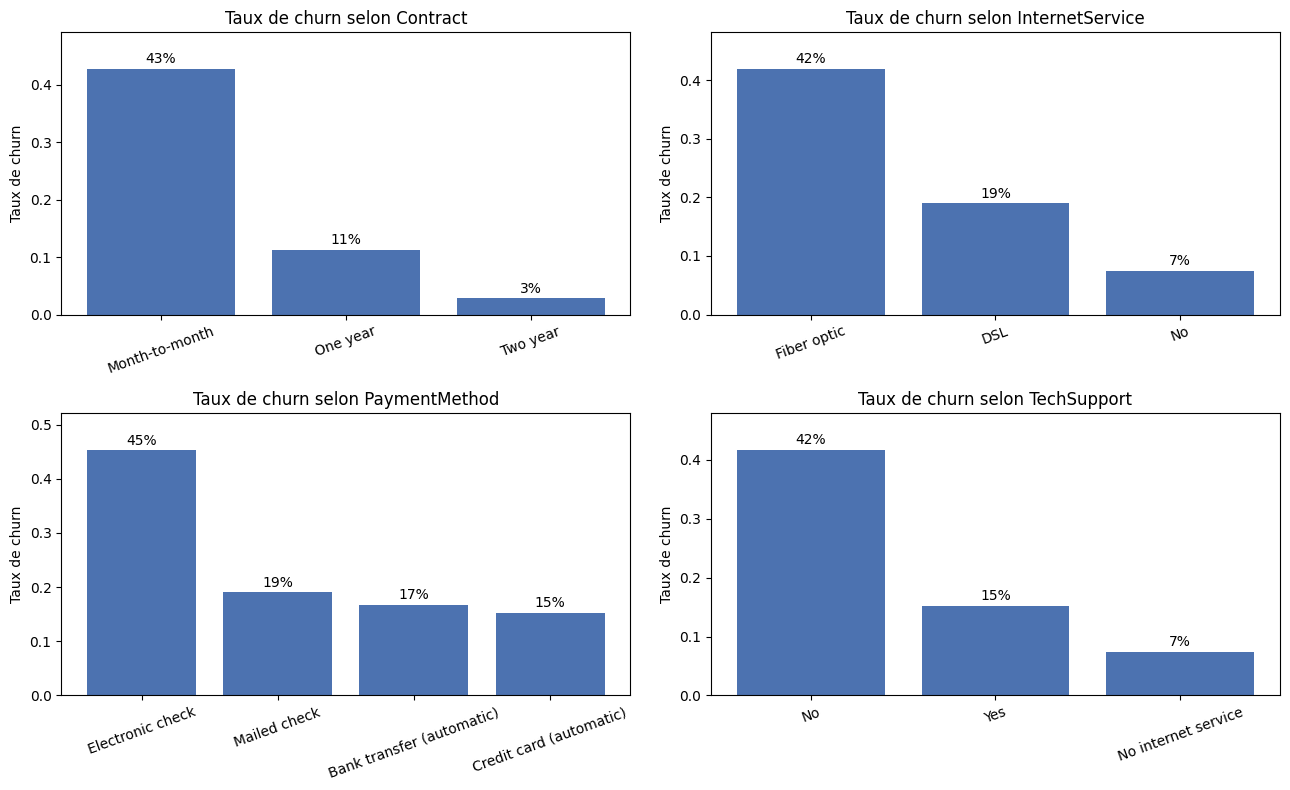

In [34]:
variables = ["Contract", "InternetService", "PaymentMethod", "TechSupport"]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, var in zip(axes.flat, variables):
    taux = df.groupby(var)["Churn"].mean().sort_values(ascending=False)
    ax.bar(taux.index, taux.values, color="#4C72B0")
    ax.set_title(f"Taux de churn selon {var}")
    ax.set_ylabel("Taux de churn")
    ax.set_ylim(0, taux.max() * 1.15)
    ax.tick_params(axis="x", rotation=20)
    for i, v in enumerate(taux.values):
        ax.text(i, v + 0.01, f"{v:.0%}", ha="center")
plt.tight_layout()
plt.show()

**Observations :**
- Le **type de contrat** est très discriminant : les clients au mois partent beaucoup plus que ceux engagés sur un ou deux ans.
- Les clients équipés de la **fibre** partent davantage que ceux en DSL, ce qui peut suggérer un problème de prix ou de qualité de service.
- Le paiement par **chèque électronique** est associé à un taux de départ nettement plus élevé que les autres moyens de paiement.
- Les clients **sans support technique** partent plus souvent.

### Ancienneté et montant mensuel

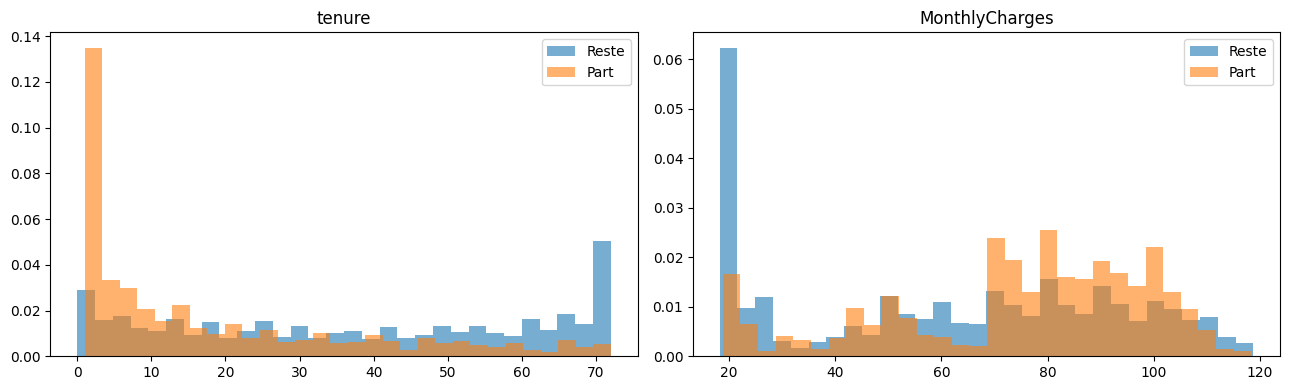

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, var in zip(axes, ["tenure", "MonthlyCharges"]):
    ax.hist(df.loc[df["Churn"] == 0, var], bins=30, alpha=0.6, label="Reste", density=True)
    ax.hist(df.loc[df["Churn"] == 1, var], bins=30, alpha=0.6, label="Part", density=True)
    ax.set_title(var)
    ax.legend()
plt.tight_layout()
plt.show()

**Observations :** les départs sont concentrés sur les **premiers mois d'abonnement**, puis deviennent rares. Les clients qui partent ont aussi tendance à payer un **montant mensuel plus élevé**.

## 5. Feature engineering

On crée deux variables à partir des observations précédentes :
- **`NbServices`** : le nombre de services souscrits (sécurité, sauvegarde, streaming…). Un client très équipé est probablement plus « attaché » à l'opérateur.
- **`TenureGroup`** : l'ancienneté regroupée en tranches, puisque le risque de départ est surtout concentré sur la première année.

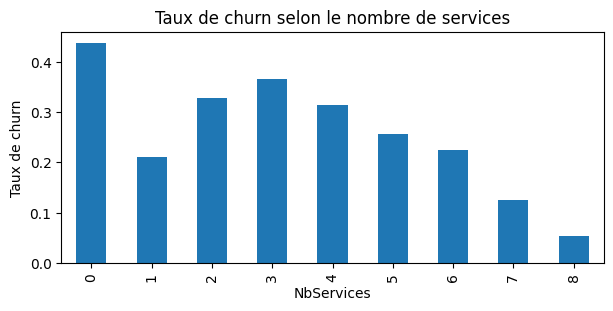

In [36]:
services = ["PhoneService", "MultipleLines", "OnlineSecurity", "OnlineBackup",
            "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]
df["NbServices"] = (df[services] == "Yes").sum(axis=1)

df["TenureGroup"] = pd.cut(df["tenure"], bins=[-1, 12, 24, 48, 72],
                           labels=["0-12 mois", "13-24 mois", "25-48 mois", "49-72 mois"]).astype(str)

df.groupby("NbServices")["Churn"].mean().plot(kind="bar", title="Taux de churn selon le nombre de services", figsize=(7, 3))
plt.ylabel("Taux de churn")
plt.show()

**Observation :** la relation n'est pas linéaire. Les clients sans aucun service partent beaucoup, puis le risque remonte entre 2 et 4 services, avant de chuter nettement chez les clients très équipés (7 ou 8 services), qui partent très rarement.

## 6. Séparation entraînement / test

La séparation est **stratifiée** pour conserver la même proportion de churners dans les deux jeux. Le jeu de test n'est utilisé qu'une seule fois, à la toute fin.

In [37]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"Entraînement : {X_train.shape[0]} clients | Test : {X_test.shape[0]} clients")

Entraînement : 5634 clients | Test : 1409 clients


## 7. Pipeline de prétraitement

Le prétraitement est intégré dans un `Pipeline` Scikit-learn :
- les variables **numériques** sont standardisées ;
- les variables **catégorielles** sont encodées en one-hot.

Ainsi, le prétraitement est réappris à l'intérieur de chaque pli de validation croisée, ce qui évite toute **fuite de données** du jeu de validation vers l'entraînement. Le pipeline complet peut aussi être sauvegardé et réutilisé tel quel sur de nouveaux clients.

In [38]:
colonnes_num = ["tenure", "MonthlyCharges", "TotalCharges", "NbServices"]
colonnes_cat = [c for c in X.columns if c not in colonnes_num]

preprocesseur = ColumnTransformer([
    ("num", StandardScaler(), colonnes_num),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), colonnes_cat),
])

def creer_pipeline(modele):
    return Pipeline([("prep", preprocesseur), ("modele", modele)])

## 8. Comparaison des modèles par validation croisée

Les quatre modèles sont évalués par **validation croisée à 5 plis** sur le jeu d'entraînement. Tous reçoivent `class_weight="balanced"`, qui donne plus de poids aux churners (minoritaires) pendant l'apprentissage : la comparaison est ainsi équitable.

In [39]:
modeles = {
    "Régression logistique": LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE),
    "Arbre de décision": DecisionTreeClassifier(class_weight="balanced", max_depth=5, random_state=RANDOM_STATE),
    "Forêt aléatoire": RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE),
    "SVM": SVC(class_weight="balanced", random_state=RANDOM_STATE),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
metriques = ["roc_auc", "recall", "precision", "f1"]

resultats = {}
for nom, modele in modeles.items():
    scores = cross_validate(creer_pipeline(modele), X_train, y_train, cv=cv, scoring=metriques)
    resultats[nom] = {m: scores[f"test_{m}"].mean() for m in metriques}

pd.DataFrame(resultats).T.round(3).sort_values("roc_auc", ascending=False)

,roc_auc,recall,precision,f1
Régression logistique,0.846,0.798,0.518,0.628
Arbre de décision,0.828,0.777,0.509,0.615
Forêt aléatoire,0.825,0.467,0.639,0.539
SVM,0.825,0.779,0.523,0.626


**Lecture :** la régression logistique obtient la meilleure AUC tout en gardant un rappel élevé. La forêt aléatoire, avec ses paramètres par défaut, sur-apprend : elle prédit bien les clients qui restent mais détecte mal ceux qui partent. On optimise ces deux modèles pour les comparer à armes égales.

## 9. Optimisation des hyperparamètres

Recherche par grille (`GridSearchCV`) avec validation croisée, en optimisant l'**AUC ROC**.

In [40]:
grilles = {
    "Régression logistique": (
        modeles["Régression logistique"],
        {"modele__C": [0.01, 0.1, 1, 10]},
    ),
    "Forêt aléatoire": (
        modeles["Forêt aléatoire"],
        {"modele__n_estimators": [200, 400],
         "modele__max_depth": [5, 8, 12],
         "modele__min_samples_leaf": [5, 10]},
    ),
}

meilleurs = {}
for nom, (modele, grille) in grilles.items():
    recherche = GridSearchCV(creer_pipeline(modele), grille, cv=cv, scoring="roc_auc", n_jobs=-1)
    recherche.fit(X_train, y_train)
    meilleurs[nom] = recherche.best_estimator_
    print(f"{nom} : AUC CV = {recherche.best_score_:.3f} | meilleurs paramètres : {recherche.best_params_}")

Régression logistique : AUC CV = 0.846 | meilleurs paramètres : {'modele__C': 10}
Forêt aléatoire : AUC CV = 0.848 | meilleurs paramètres : {'modele__max_depth': 8, 'modele__min_samples_leaf': 10, 'modele__n_estimators': 200}


## 10. Évaluation finale sur le jeu de test

In [41]:
for nom, modele in meilleurs.items():
    y_pred = modele.predict(X_test)
    y_proba = modele.predict_proba(X_test)[:, 1]
    print(f"===== {nom} =====")
    print(f"AUC ROC : {roc_auc_score(y_test, y_proba):.3f}")
    print(classification_report(y_test, y_pred, target_names=["Reste", "Part"], digits=3))

===== Régression logistique =====
AUC ROC : 0.841
              precision    recall  f1-score   support

       Reste      0.904     0.715     0.798      1035
        Part      0.500     0.789     0.612       374

    accuracy                          0.735      1409
   macro avg      0.702     0.752     0.705      1409
weighted avg      0.796     0.735     0.749      1409

===== Forêt aléatoire =====
AUC ROC : 0.844
              precision    recall  f1-score   support

       Reste      0.908     0.748     0.820      1035
        Part      0.531     0.791     0.636       374

    accuracy                          0.759      1409
   macro avg      0.720     0.770     0.728      1409
weighted avg      0.808     0.759     0.771      1409



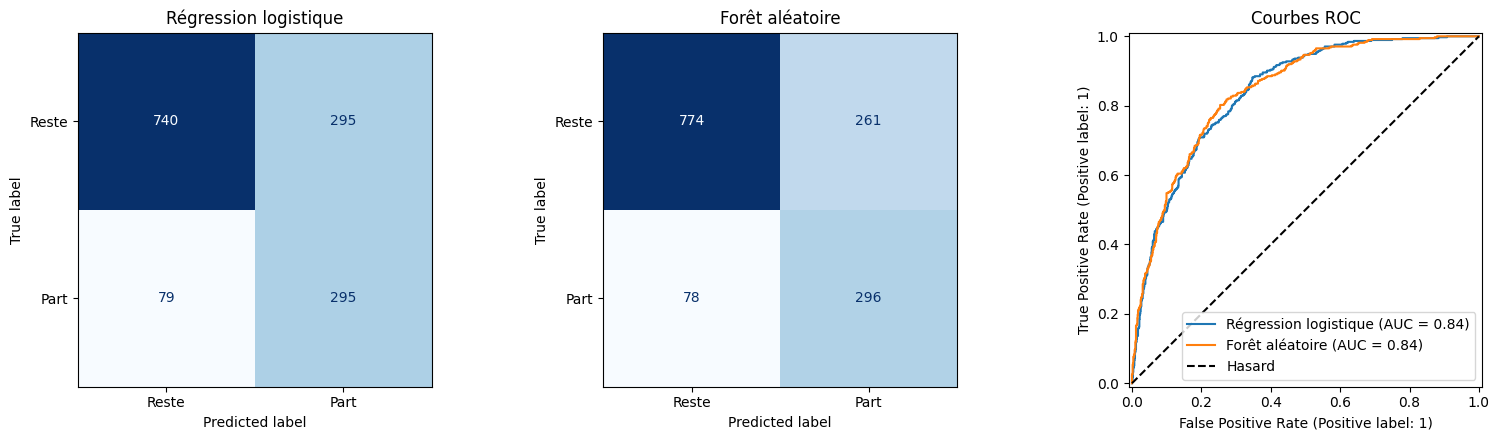

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (nom, modele) in zip(axes[:2], meilleurs.items()):
    ConfusionMatrixDisplay.from_estimator(modele, X_test, y_test, display_labels=["Reste", "Part"],
                                          cmap="Blues", colorbar=False, ax=ax)
    ax.set_title(nom)
for nom, modele in meilleurs.items():
    RocCurveDisplay.from_estimator(modele, X_test, y_test, name=nom, ax=axes[2])
axes[2].plot([0, 1], [0, 1], "k--", label="Hasard")
axes[2].set_title("Courbes ROC")
axes[2].legend()
plt.tight_layout()
plt.show()

**Choix du modèle final :** la forêt aléatoire optimisée est retenue, car c'est elle qui obtient la meilleure AUC en validation croisée. Le choix se fait sur la validation croisée et non sur le jeu de test, pour que le score de test reste une estimation honnête des performances réelles. Sur le test, les deux modèles sont d'ailleurs très proches, et la régression logistique reste une alternative valable, plus simple et plus rapide.

## 11. Interprétation : quels facteurs expliquent le départ ?

On mesure l'importance de chaque variable par **permutation** : on mélange aléatoirement les valeurs d'une variable dans le jeu de test et on observe la baisse d'AUC. Plus la baisse est forte, plus le modèle dépend de cette variable. Cette méthode fonctionne avec n'importe quel modèle et raisonne sur les variables d'origine (avant encodage), ce qui la rend facile à lire.

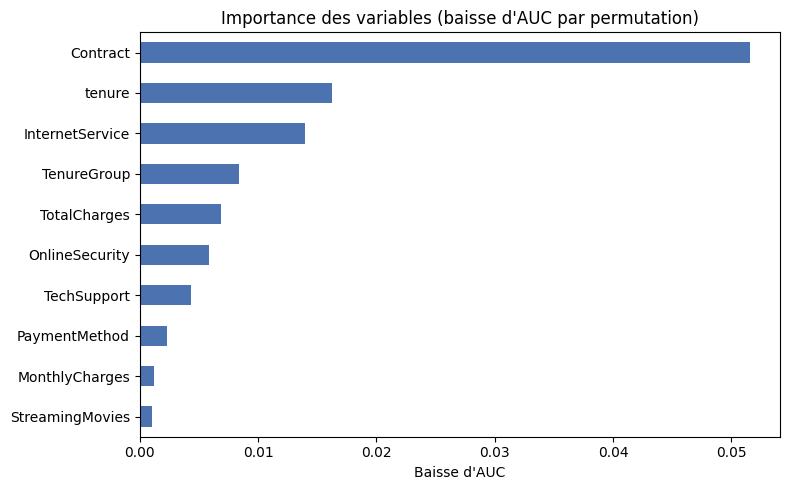

In [43]:
modele_final = meilleurs["Forêt aléatoire"]

importance = permutation_importance(modele_final, X_test, y_test, scoring="roc_auc",
                                    n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)
importance = pd.Series(importance.importances_mean, index=X_test.columns).sort_values()

importance.tail(10).plot(kind="barh", figsize=(8, 5), color="#4C72B0",
                         title="Importance des variables (baisse d'AUC par permutation)")
plt.xlabel("Baisse d'AUC")
plt.tight_layout()
plt.show()

**Lecture :** le **type de contrat** est de loin le facteur le plus déterminant, suivi de l'**ancienneté** et du **type de connexion internet**. Viennent ensuite les services de sécurité en ligne et de support technique. Croisé avec l'analyse exploratoire, cela donne le sens de l'effet : contrat au mois, faible ancienneté et fibre optique augmentent le risque de départ.

À noter : les deux variables créées (`NbServices`, `TenureGroup`) n'apportent qu'un gain limité, car leur information est déjà largement contenue dans les variables d'origine.

## 12. Sauvegarde du modèle

Le pipeline complet (prétraitement + modèle) est sauvegardé : il peut être rechargé pour prédire directement sur de nouvelles données brutes, sans refaire le prétraitement à la main.

In [44]:
import joblib

joblib.dump(modele_final, "modele_churn.joblib")

# Exemple de réutilisation : probabilité de départ pour 5 clients
modele_charge = joblib.load("modele_churn.joblib")
modele_charge.predict_proba(X_test.head())[:, 1].round(2)

array([0.06, 0.83, 0.16, 0.58, 0.06])

## 13. Conclusion

<!-- Résultats obtenus avec random_state=42. Vérifie qu'ils sont identiques après ton exécution. -->

- Le modèle retenu, une **forêt aléatoire optimisée et pondérée**, détecte **79 %** des clients qui partent sur le jeu de test, avec une **AUC de 0,84** et une précision de 53 %. En pratique, sur 10 clients signalés comme à risque, environ 5 partiraient réellement.
- La **régression logistique** obtient des résultats presque identiques, ce qui montre que le problème est en grande partie linéaire.
- La **pondération des classes** a été décisive : sans elle, la forêt aléatoire ne détectait que 47 % des départs.
- **Facteurs de risque principaux :** contrat au mois, faible ancienneté, fibre optique, absence de sécurité en ligne et de support technique.

**Recommandation métier :** cibler en priorité les nouveaux clients en contrat mensuel, par exemple avec une offre incitant à passer à un engagement d'un an.

**Pistes d'amélioration :** ajuster le seuil de décision selon le coût réel d'une action de fidélisation, tester des modèles de boosting (XGBoost, LightGBM), et analyser plus finement le cas des clients fibre.